#BERT 모델 실습

### 데이터 소환

In [1]:
!pip install -q Korpora

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.8/57.8 kB 6.3 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
from Korpora import Korpora

corpus = Korpora.load("nsmc")
df = pd.DataFrame(corpus.test).sample(20000, random_state=42)
train, valid, test = np.split(
    df.sample(frac=1, random_state=42),[int(0.6*len(df)), int(0.8*len(df))]
)

print(train.head(5).to_markdown())
print(f"Training Data Size: {len(train)}")
print(f"Validation Data Size: {len(valid)}")
print(f"Testing Data Size: {len(test)}")



    Korpora 는 다른 분들이 연구 목적으로 공유해주신 말뭉치들을
    손쉽게 다운로드, 사용할 수 있는 기능만을 제공합니다.

    말뭉치들을 공유해 주신 분들에게 감사드리며, 각 말뭉치 별 설명과 라이센스를 공유 드립니다.
    해당 말뭉치에 대해 자세히 알고 싶으신 분은 아래의 description 을 참고,
    해당 말뭉치를 연구/상용의 목적으로 이용하실 때에는 아래의 라이센스를 참고해 주시기 바랍니다.

    # Description
    Author : e9t@github
    Repository : https://github.com/e9t/nsmc
    References : www.lucypark.kr/docs/2015-pyconkr/#39

    Naver sentiment movie corpus v1.0
    This is a movie review dataset in the Korean language.
    Reviews were scraped from Naver Movies.

    The dataset construction is based on the method noted in
    [Large movie review dataset][^1] from Maas et al., 2011.

    [^1]: http://ai.stanford.edu/~amaas/data/sentiment/

    # License
    CC0 1.0 Universal (CC0 1.0) Public Domain Dedication
    Details in https://creativecommons.org/publicdomain/zero/1.0/



[nsmc] download ratings_train.txt: 14.6MB [00:00, 346MB/s]
[nsmc] download ratings_test.txt: 4.90MB [00:00, 203MB/s]


|       | text                                                     |   label |
|------:|:---------------------------------------------------------|--------:|
| 26891 | 역시 코믹액션은 성룡, 홍금보, 원표 삼인방이 최고지!!     |       1 |
| 25024 | 점수 후하게 줘야것네 별 반개~                            |       0 |
| 11666 | 오랜만에 느낄수 있는 [감독] 구타욕구.                    |       0 |
| 40303 | 본지는 좀 됬지만 극장서 돈주고 본게 아직까지 아까운 영화 |       0 |
| 18010 | 징키스칸이란 소재를 가지고 이것밖에 못만드냐             |       0 |
Training Data Size: 12000
Validation Data Size: 4000
Testing Data Size: 4000


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [3]:
#BERT 입력 텐서 생성
import torch
from transformers import BertTokenizer
from torch.utils.data import TensorDataset, DataLoader
from torch.utils.data import RandomSampler, SequentialSampler

def make_dataset(data, tokenizer, device):
  tokenized = tokenizer(
      text=data.text.tolist(),
      padding= "longest",
      truncation = True,
      return_tensors="pt"
  )
  input_ids = tokenized["input_ids"].to(device)
  attention_mask = tokenized["attention_mask"].to(device)
  labels = torch.tensor(data.label.values, dtype=torch.long).to(device)
  return TensorDataset(input_ids, attention_mask, labels)

def get_dataloader(dataset, sampler, batch_size):
  data_sampler = sampler(dataset)
  dataloader = DataLoader(dataset, sampler=data_sampler, batch_size = batch_size)
  return dataloader

epochs = 5
batch_size = 32
device = "cuda" if torch.cuda.is_available() else "cpu"
tokenizer = BertTokenizer.from_pretrained(
    pretrained_model_name_or_path = "bert-base-multilingual-cased",
    do_lower_case = False,
    )

train_dataset = make_dataset(train, tokenizer, device)
train_dataloader = get_dataloader(train_dataset, RandomSampler, batch_size)

valid_dataset = make_dataset(valid, tokenizer, device)
valid_dataloader = get_dataloader(valid_dataset, SequentialSampler, batch_size)

test_dataset = make_dataset(test, tokenizer, device)
test_dataloader = get_dataloader(test_dataset, SequentialSampler, batch_size)

print(train_dataset[0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

(tensor([   101,  58466,   9812, 118956, 119122,  59095,  10892,   9434, 118888,
           117,   9992,  40032,  30005,    117,   9612,  37824,   9410,  12030,
         42337,  10739,  83491,  12508,    106,    106,    102,      0,      0,
             0,      0,      0,      0,      0,      0,      0,      0,      0,
             0,      0,      0,      0,      0,      0,      0,      0,      0,
             0,      0,      0,      0,      0,      0,      0,      0,      0,
             0,      0,      0,      0,      0,      0,      0,      0,      0,
             0,      0,      0,      0,      0,      0,      0,      0,      0,
             0,      0,      0,      0,      0,      0,      0,      0,      0,
             0,      0,      0,      0,      0,      0,      0,      0,      0,
             0,      0,      0,      0,      0,      0,      0,      0,      0,
             0,      0,      0,      0,      0,      0,      0,      0,      0,
             0,      0,      0,      0,

* 사전 학습된 모델은 bert-base-multilingual-cased로 다중 언어를 지원
* 대소문자를 유지하는 사전 학습된 BERT 모델을 의미
* do_lower_case: 소문자 유지(True-> apple과 Apple을 다른 단어로 인식)
* get_dataloader 함수는 샘플러 클래스를 활용해 데이터를 목적에 따라 샘플링
* 무작위 샘플러 클래스는 데이터를 무작위로 샘플링(학습에 적용), 시퀀셜 샘플러 클래서는 데이터를 고정된 순서대로 반환(검증 및 평가 배치에 적용)

In [4]:
#BERT 모델 선언
from torch import optim
from transformers import BertForSequenceClassification #문장 분류 모델

model = BertForSequenceClassification.from_pretrained(
    pretrained_model_name_or_path = "bert-base-multilingual-cased",
    num_labels = 2
).to(device)
optimizer = optim.AdamW(model.parameters(), lr = 1e-5, eps=1e-8)

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


* AdamW: Adam 최적화 함수에 가중치 감쇠를 추가한 변형된 경사 하강법 알고리즘
*AdamW 클래스의 eps 매개변수는 학습률을 0으로 나누는 것을 방지하기 위해 분모에 더하는 작은 값
* AdamW로 매개변수의 학습률 조절

In [5]:
#모델 구조 코드
from transformers import BertForSequenceClassification

model = BertForSequenceClassification.from_pretrained(
    pretrained_model_name_or_path = "bert-base-multilingual-cased")

for main_name, main_module in model.named_children():
    print(main_name)
    for sub_name, sub_module in main_module.named_children():
        print("└ ", sub_name)
        for ssub_name, ssub_module in sub_module.named_children():
            print("|  └ ", ssub_name)
            for sssub_name, sssub_module in ssub_module.named_children():
                print("|  |  └ ", sssub_name)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


bert
└  embeddings
|  └  word_embeddings
|  └  position_embeddings
|  └  token_type_embeddings
|  └  LayerNorm
|  └  dropout
└  encoder
|  └  layer
|  |  └  0
|  |  └  1
|  |  └  2
|  |  └  3
|  |  └  4
|  |  └  5
|  |  └  6
|  |  └  7
|  |  └  8
|  |  └  9
|  |  └  10
|  |  └  11
└  pooler
|  └  dense
|  └  activation
dropout
classifier


* 트랜스포머 인코더 블록은 총 12개를 사용, 각각의 블록은 입력 시퀀스를 순차적으로 처리해 새로운 임베딩을 생성
* 각 블록은 셀프 어텐션 및 순방향 신경망을 사용해 입력 시퀀스의 다양한 관계를 학습
* pooler는 [CLS] 토큰 벡터를 한 번 더 비선형 변환을 수행하기 위해 선형 변화과 비선형 변환인 Tanh 함수를 사용. 이후 드롭 아웃이 적용돼 모델의 과대적합 방지

In [6]:
#모델 학습 및 검증
import numpy as np
from torch import nn
import torch
import os
from transformers import BertForSequenceClassification
from torch import optim

def calc_accuracy(preds, labels):
  pred_flat = np.argmax(preds, axis = 1).flatten()
  labels_flat = labels.flatten()
  return np.sum(pred_flat == labels_flat) / len(labels_flat)

def train(model, optimizer, dataloader):
  model.train()
  train_loss = 0.0

  for input_ids, attention_mask, labels in dataloader:
    outputs = model(
        input_ids = input_ids,
        attention_mask = attention_mask,
        labels = labels
    )
    loss = outputs.loss
    train_loss += loss.item()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
  train_loss = train_loss / len(dataloader)
  return train_loss

def evaluation(model, dataloader):
  with torch.no_grad():
    model.eval()
    criterion = nn.CrossEntropyLoss()
    val_loss, val_accuracy = 0.0, 0.0
    for input_ids, attention_mask, labels in dataloader:
      outputs = model(
          input_ids = input_ids,
          attention_mask = attention_mask,
          labels = labels
      )
      logits = outputs.logits

      loss = criterion(logits, labels)
      logits = logits.detach().cpu().numpy()
      label_ids = labels.to("cpu").numpy()
      accuracy = calc_accuracy(logits, label_ids)

      val_loss += loss
      val_accuracy += accuracy

    val_loss = val_loss / len(dataloader)
    val_accuracy = val_accuracy / len(dataloader)
    return val_loss, val_accuracy

best_loss = 10000

# Create the directory for saving models if it doesn't exist
output_dir = "../models"
os.makedirs(output_dir, exist_ok=True)

# Re-initialize the BERT model and optimizer here to ensure consistency with BertTokenizer
model = BertForSequenceClassification.from_pretrained(
    pretrained_model_name_or_path = "bert-base-multilingual-cased",
    num_labels = 2
).to(device)
optimizer = optim.AdamW(model.parameters(), lr = 1e-5, eps=1e-8)


for epoch in range(epochs):
  train_loss = train(model, optimizer, train_dataloader)
  val_loss, val_accuracy = evaluation(model, valid_dataloader)
  print(f"Epoch: {epoch +1}: Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}")

  if val_loss < best_loss:
    best_loss = val_loss
    # Save the model with a name consistent with BERT
    torch.save(model.state_dict(), os.path.join(output_dir, "BertForSequenceClassification.pt"))
    print("Saved the model weights")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch: 1: Train Loss: 0.5590, Val Loss: 0.4478, Val Accuracy: 0.7853
Saved the model weights
Epoch: 2: Train Loss: 0.4078, Val Loss: 0.4363, Val Accuracy: 0.8077
Saved the model weights
Epoch: 3: Train Loss: 0.3241, Val Loss: 0.4145, Val Accuracy: 0.8175
Saved the model weights
Epoch: 4: Train Loss: 0.2515, Val Loss: 0.4461, Val Accuracy: 0.8185
Epoch: 5: Train Loss: 0.1925, Val Loss: 0.5118, Val Accuracy: 0.8147


In [7]:
from transformers import BertForSequenceClassification
import torch

model = BertForSequenceClassification.from_pretrained(
    pretrained_model_name_or_path = "bert-base-multilingual-cased",
    num_labels = 2
).to(device)
# The line below is not necessary for BERT models and was likely added for GPT2 compatibility.
# model.config.pad_token_id = model.config.eos_token_id
model.load_state_dict(torch.load("../models/BertForSequenceClassification.pt"))

test_loss, test_accuracy = evaluation(model, test_dataloader)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Test Loss: 0.4137, Test Accuracy: 0.8203


#BART 모델 실습

In [8]:
!pip install datasets

In [9]:
import numpy as np
from datasets import load_dataset

news = load_dataset("argilla/news-summary", split="test")
df = news.to_pandas().sample(5000, random_state=42)[["text", "prediction"]]
df["prediction"] = df["prediction"].map(lambda x: x[0]["text"])
train, valid, test = np.split(
    df.sample(frac=1, random_state=42),[int(0.6*len(df)), int(0.8*len(df))]
)

print(f"Source News: {train.text.iloc[0][:200]}")
print(f"Summarization: {train.prediction.iloc[0][:50]}")
print(f"Training Data Size: {len(train)}")
print(f"Validation Data Size: {len(valid)}")
print(f"Testing Data Size: {len(test)}")

README.md:   0%|          | 0.00/2.02k [00:00<?, ?B/s]

data/train-00000-of-00001-ebc48879f34571(…):   0%|          | 0.00/1.54M [00:00<?, ?B/s]

data/test-00000-of-00001-6227bd8eb10a9b5(…):   0%|          | 0.00/31.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/20417 [00:00<?, ? examples/s]

Source News: DANANG, Vietnam (Reuters) - Russian President Vladimir Putin said on Saturday he had a normal dialogue with U.S. leader Donald Trump at a summit in Vietnam, and described Trump as civil, well-educated
Summarization: Putin says had useful interaction with Trump at Vi
Training Data Size: 3000
Validation Data Size: 1000
Testing Data Size: 1000


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [10]:
#뉴스 요약 데이터셋 불러오기
import numpy as np
from datasets import load_dataset

news = load_dataset("argilla/news-summary", split="test")
df = news.to_pandas().sample(5000, random_state=42)[["text", "prediction"]]
df["prediction"] = df["prediction"].map(lambda x: x[0]["text"])
train, valid, test = np.split(
    df.sample(frac=1, random_state=42),[int(0.6*len(df)), int(0.8*len(df))]
)

print(f"Source News: {train.text.iloc[0][:200]}")
print(f"Summarization: {train.prediction.iloc[0][:50]}")
print(f"Training Data Size: {len(train)}")
print(f"Validation Data Size: {len(valid)}")
print(f"Testing Data Size: {len(test)}")

Source News: DANANG, Vietnam (Reuters) - Russian President Vladimir Putin said on Saturday he had a normal dialogue with U.S. leader Donald Trump at a summit in Vietnam, and described Trump as civil, well-educated
Summarization: Putin says had useful interaction with Trump at Vi
Training Data Size: 3000
Validation Data Size: 1000
Testing Data Size: 1000


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [11]:
#BART 입력 텐서 생성
import torch
from transformers import BartTokenizer
from torch.utils.data import TensorDataset, DataLoader
from torch.utils.data import RandomSampler, SequentialSampler
from torch.nn.utils.rnn import pad_sequence

def make_dataset(data, tokenizer, device):
  tokenized = tokenizer(
      text=data.text.tolist(),
      padding= "longest",
      truncation = True,
      return_tensors="pt"
  )
  labels_list = [] # Changed 'lables' to 'labels_list' for clarity and to avoid conflict
  input_ids = tokenized["input_ids"].to(device)
  attention_mask = tokenized["attention_mask"].to(device)
  for target in data.prediction: # Corrected from data.prediction()
      labels_list.append(tokenizer.encode(target, return_tensors="pt").squeeze())
  labels = pad_sequence(labels_list, batch_first = True, padding_value = -100).to(device)
  #padding = -100 -> 교차 엔트로피와 같은 손실 함수에서 패딩된 토큰을 무시하게 하기 위해 사용
  return TensorDataset(input_ids, attention_mask, labels)

def get_dataloader(dataset, sampler, batch_size):
  data_sampler = sampler(dataset)
  dataloader = DataLoader(dataset, sampler=data_sampler, batch_size = batch_size)
  return dataloader

epochs = 3
batch_size = 8
device = "cuda" if torch.cuda.is_available() else "cpu"
tokenizer = BartTokenizer.from_pretrained(
    pretrained_model_name_or_path = "facebook/bart-base"
)

train_dataset = make_dataset(train, tokenizer, device)
train_dataloader = get_dataloader(train_dataset, RandomSampler, batch_size)

valid_dataset = make_dataset(valid, tokenizer, device)
valid_dataloader = get_dataloader(valid_dataset, SequentialSampler, batch_size)

test_dataset = make_dataset(test, tokenizer, device)
test_dataloader = get_dataloader(test_dataset, SequentialSampler, batch_size)

print(train_dataset[0])

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

(tensor([   0,  495, 1889,  ...,    1,    1,    1], device='cuda:0'), tensor([1, 1, 1,  ..., 0, 0, 0], device='cuda:0'), tensor([    0, 35891,   161,    56,  5616, 10405,    19,   140,    23,  5490,
         3564,     2,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,
         -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100],
       device='cuda:0'))


In [12]:
from torch import optim
from transformers import BartForConditionalGeneration

model = BartForConditionalGeneration.from_pretrained(
    pretrained_model_name_or_path = "facebook/bart-base"
).to(device)
optimizer = optim.AdamW(model.parameters(), lr = 5e-5, eps = 1e-8)

config.json:   0%|          | 0.00/1.72k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/558M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

In [13]:
#모델 구조 코드
from transformers import BartForConditionalGeneration

model = BartForConditionalGeneration.from_pretrained(
    pretrained_model_name_or_path = "facebook/bart-base")

for main_name, main_module in model.named_children():
    print(main_name)
    for sub_name, sub_module in main_module.named_children():
        print("└ ", sub_name)
        for ssub_name, ssub_module in sub_module.named_children():
            print("|  └ ", ssub_name)
            for sssub_name, sssub_module in ssub_module.named_children():
                print("|  |  └ ", sssub_name)

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

model
└  shared
└  encoder
|  └  embed_tokens
|  └  embed_positions
|  └  layers
|  |  └  0
|  |  └  1
|  |  └  2
|  |  └  3
|  |  └  4
|  |  └  5
|  └  layernorm_embedding
└  decoder
|  └  embed_tokens
|  └  embed_positions
|  └  layers
|  |  └  0
|  |  └  1
|  |  └  2
|  |  └  3
|  |  └  4
|  |  └  5
|  └  layernorm_embedding
lm_head


* BART는 6개의 인코더와 디코더 계층으로 구성, 마지막 연산에서는 layernorm_embedding 계층을 통과
* layernorm_embedding 계층은 인코더와 디코더에서 각 토큰의 임베딩에 적용되는 계층 정규화로 임베딩 벡터의 마지막 차원에 대해 정규화를 수행
* 인코더의 마지막 계층의 출력값은 디코더의 모든 계층과 어텐션 연산을 수행. 마지막 디코더 계층의 출력값은 출력 크기가 단어 사전의 크기인 완전 연결 계층을 통과해 언어 모델 형성
* 모델 평가 방법: 문장 생성 기법에서 자주 사용되는 루지(ROUGE) 점수를 사용-> 생성된 요약문과 정답 요약문이 얼마나 유사한지 평가하기 위해 토큰의 N-gram 정밀도와 재현율 이용해 평가
* N-gram 사용->ROUNGE-N

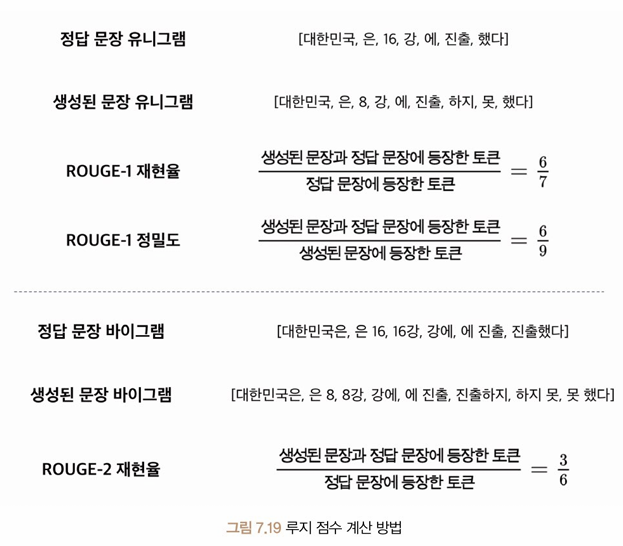

* ROUGE-N, ROUGE-L, ROUGE-LSUM, ROUGE-W
* ROUGE-L: 생성된 요약문과 정답 요약문 사이에서 최장 공통부분 수열(Longerst Commen Subsequence, LCS) 기반의 통계 방식
> LCS: 두 문장 사이에 공통으로 존재하는 가장 긴 부분 문자열을 찾음
* ROUGE-LSUM: ROUGE-L의 변형으로 텍스트 내의 개행 문자를 문장 경계로 인식. 각 문장 쌍에 대해 LCS를 계산한 후, union-LCS라는 값을 계산
> union-LCS: 각 문장 쌍의 LCS를 합집합한 것, 중복된 부분을 제거한 후 길이를 계산
* ROUGE-W: 가중치가 적용된 LCS 방법으로 연속된 LCS에 가중치 부여. 해당 부분 문자열 내의 단어에 가중치 부여

In [14]:
!pip install evaluate rouge_score absl_py

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.0 MB/s eta 0:00:00
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=0e1a8307c4fc41fd2425cad2a436cacab0e8c4f1dfb37c45fe288cc634470eac
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge_score


In [18]:
import numpy as np
import evaluate
import torch
import os
from transformers import BartForConditionalGeneration
from torch import optim
from transformers import BartTokenizer # Ensure BartTokenizer is imported here for tokenizer access
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
from torch.nn.utils.rnn import pad_sequence

# Define device at the top of the cell
device = "cuda" if torch.cuda.is_available() else "cpu"

os.environ["CUDA_LAUNCH_BLOCKING"] = "1" # Forcing synchronous CUDA operations for better error tracing

def calc_rouge(preds, labels):
  preds = preds.argmax(axis=-1)
  labels = np.where(labels != -100, labels, tokenizer.pad_token_id)

  decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)
  decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

  rouge2=rouge_score.compute(
      predictions = decoded_preds,
      references = decoded_labels
  )
  return rouge2["rouge2"]

#모델 학습 및 검증
def train(model, optimizer, dataloader):
  model.train()
  train_loss = 0.0

  for batch_idx, (input_ids, attention_mask, labels) in enumerate(dataloader):
    input_ids = input_ids.to(device)
    attention_mask = attention_mask.to(device)
    labels = labels.to(device)
    # Explicitly create decoder_input_ids and labels for loss
    decoder_input_ids = labels[:, :-1].contiguous()
    # Replace any -100 in decoder_input_ids with pad_token_id for valid token IDs
    decoder_input_ids[decoder_input_ids == -100] = tokenizer.pad_token_id

    labels_for_loss = labels[:, 1:].contiguous()

    # Diagnostic prints (removed - they were for previous error stages)

    outputs = model(
        input_ids = input_ids,
        attention_mask = attention_mask,
        decoder_input_ids = decoder_input_ids, # Pass explicit decoder_input_ids
        labels = labels_for_loss # Pass explicit labels for loss
    )
    loss = outputs.loss
    train_loss += loss.item()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
  train_loss = train_loss / len(dataloader)
  return train_loss

def evaluation(model, dataloader):
  with torch.no_grad():
    model.eval()
    val_loss, val_rouge = 0.0, 0.0

    for batch_idx, (input_ids, attention_mask, labels) in enumerate(dataloader):

      outputs = model(
          input_ids = input_ids,
          attention_mask = attention_mask,
          labels = labels
      )
      logits = outputs.logits
      loss = outputs.loss

      logits = logits.detach().cpu().numpy()
      label_ids = labels.to("cpu").numpy() # Use the original labels from dataloader for calc_rouge

      rouge = calc_rouge(logits, label_ids)

      val_loss += loss
      val_rouge += rouge

    val_loss = val_loss / len(dataloader)
    val_rouge = val_rouge / len(dataloader)
    return val_loss, val_rouge

# Create the directory for saving models if it doesn't exist
output_dir = "../models"
os.makedirs(output_dir, exist_ok=True)

# Define tokenizer here as well to ensure it's available for model config setup
# This is a re-definition from BYW5IAUc8xkk, but necessary for this cell's context
# It is important that this tokenizer matches the one used for dataset creation
tokenizer = BartTokenizer.from_pretrained(
    pretrained_model_name_or_path = "facebook/bart-base"
)

# Corrected: evaluate.load("rouge") does not take tokenizer argument
rouge_score = evaluate.load("rouge", tokenizer=tokenizer)
best_loss = 10000

# Define epochs and batch_size here
epochs = 3
batch_size = 8

# Re-define make_dataset and get_dataloader functions for this cell
def make_dataset(data, tokenizer, device):
  tokenized = tokenizer(
      text=data.text.tolist(),
      padding= "longest",
      truncation = True,
      return_tensors="pt"
  )
  labels_list = [] # Changed 'lables' to 'labels_list' for clarity and to avoid conflict
  input_ids = tokenized["input_ids"].to(device)
  attention_mask = tokenized["attention_mask"].to(device)
  for target in data.prediction: # Corrected from data.prediction()
      labels_list.append(tokenizer.encode(target, return_tensors="pt").squeeze())
  labels = pad_sequence(labels_list, batch_first = True, padding_value = -100).to(device)
  #padding = -100 -> 교차 엔트로피와 같은 손실 함수에서 패딩된 토큰을 무시하게 하기 위해 사용
  return TensorDataset(input_ids, attention_mask, labels)

def get_dataloader(dataset, sampler, batch_size):
  data_sampler = sampler(dataset)
  dataloader = DataLoader(dataset, sampler=data_sampler, batch_size = batch_size)
  return dataloader

# Re-create dataloaders for this cell
train_dataset = make_dataset(train, tokenizer, device)
train_dataloader = get_dataloader(train_dataset, RandomSampler, batch_size)

valid_dataset = make_dataset(valid, tokenizer, device)
valid_dataloader = get_dataloader(valid_dataset, SequentialSampler, batch_size)

test_dataset = make_dataset(test, tokenizer, device)
test_dataloader = get_dataloader(test_dataset, SequentialSampler, batch_size)

model = BartForConditionalGeneration.from_pretrained(
    pretrained_model_name_or_path = "facebook/bart-base"
)
# Explicitly set special token IDs in model config to match tokenizer
model.config.pad_token_id = tokenizer.pad_token_id
model.config.eos_token_id = tokenizer.eos_token_id
model.config.bos_token_id = tokenizer.bos_token_id
# Critical for BART: ensure decoder_start_token_id is set to eos_token_id for generation
model.config.decoder_start_token_id = tokenizer.eos_token_id # Corrected back to eos_token_id

model.to(device) # Removed .float() cal
optimizer = optim.AdamW(model.parameters(), lr = 1e-5, eps=1e-8)


for epoch in range(epochs):
  train_loss = train(model, optimizer, train_dataloader)
  val_loss, val_rouge = evaluation(model, valid_dataloader)
  print(f"Epoch: {epoch +1}: Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val ROUGE: {val_rouge:.4f}") # Corrected from val_accuracy to val_rouge

  if val_loss < best_loss:
    best_loss = val_loss
    # Save the model with a name consistent with BERT
    torch.save(model.state_dict(), os.path.join(output_dir, "BartForConditionalGeneration.pt"))
    print("Saved the model weights")

AttributeError: 'function' object has no attribute 'text'

**#colab RAM 문제로 인해서 코드가 돌아가질 않음**

* calc_rouge: 텍스트 요약 작업에서 모델이 예측한 요약문과 정답 요약문 사이의 루지 점수를 계산하는 함수
* labels: 정답 요약문

In [19]:
#BART모델 평가
model = BartForConditionalGeneration.from_pretrained(
    pretrained_model_name_or_path = "facebook/bart-base"
  ).to(device)
model.load_state_dict(torch.load("../models/BartForConditionalGeneration.pt"))

test_loss, test_rouge_score = evaluation(model, test_dataloader)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test ROUGE-2 Score: {test_rouge_score:.4f}")

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

FileNotFoundError: [Errno 2] No such file or directory: '../models/BartForConditionalGeneration.pt'

* ROUGE-2는 0에서 1사이의 값을 가짐. 1에 가까울수록 높은 성능

In [20]:
#문장 요약문 비교
from transformers import pipeline

summarizer = pipeline(
    tast = "summarization",
    model = model,
    tokenizer = tokenizer,
    max_length = 54,
    device = "cpu"
)
for index in range(5):
  news_text = test.text.iloc[index]
  summarization = test.prediction.iloc[index]
  predicted_summarization = summarizer(news_text)[0]["summary_text"]
  print(f"정답 요약문: {summarization}")
  print(f"모델 요약문:{predicted_summarization}")

RuntimeError: Inferring the task automatically requires to check the hub with a model_id defined as a `str`. BartForConditionalGeneration(
  (model): BartModel(
    (shared): BartScaledWordEmbedding(50265, 768, padding_idx=1)
    (encoder): BartEncoder(
      (embed_tokens): BartScaledWordEmbedding(50265, 768, padding_idx=1)
      (embed_positions): BartLearnedPositionalEmbedding(1026, 768)
      (layers): ModuleList(
        (0-5): 6 x BartEncoderLayer(
          (self_attn): BartAttention(
            (k_proj): Linear(in_features=768, out_features=768, bias=True)
            (v_proj): Linear(in_features=768, out_features=768, bias=True)
            (q_proj): Linear(in_features=768, out_features=768, bias=True)
            (out_proj): Linear(in_features=768, out_features=768, bias=True)
          )
          (self_attn_layer_norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=768, out_features=307

# ELECTRA 모델 실습

In [21]:
!pip install -q Korpora

In [23]:
import numpy as np
import pandas as pd
from Korpora import Korpora

corpus = Korpora.load("nsmc")
df = pd.DataFrame(corpus.test).sample(20000, random_state=42)
train, valid, test = np.split(
    df.sample(frac=1, random_state=42),[int(0.6*len(df)), int(0.8*len(df))]
)

print(train.head(5).to_markdown())
print(f"Training Data Size: {len(train)}")
print(f"Validation Data Size: {len(valid)}")
print(f"Testing Data Size: {len(test)}")



    Korpora 는 다른 분들이 연구 목적으로 공유해주신 말뭉치들을
    손쉽게 다운로드, 사용할 수 있는 기능만을 제공합니다.

    말뭉치들을 공유해 주신 분들에게 감사드리며, 각 말뭉치 별 설명과 라이센스를 공유 드립니다.
    해당 말뭉치에 대해 자세히 알고 싶으신 분은 아래의 description 을 참고,
    해당 말뭉치를 연구/상용의 목적으로 이용하실 때에는 아래의 라이센스를 참고해 주시기 바랍니다.

    # Description
    Author : e9t@github
    Repository : https://github.com/e9t/nsmc
    References : www.lucypark.kr/docs/2015-pyconkr/#39

    Naver sentiment movie corpus v1.0
    This is a movie review dataset in the Korean language.
    Reviews were scraped from Naver Movies.

    The dataset construction is based on the method noted in
    [Large movie review dataset][^1] from Maas et al., 2011.

    [^1]: http://ai.stanford.edu/~amaas/data/sentiment/

    # License
    CC0 1.0 Universal (CC0 1.0) Public Domain Dedication
    Details in https://creativecommons.org/publicdomain/zero/1.0/

[Korpora] Corpus `nsmc` is already installed at /root/Korpora/nsmc/ratings_train.txt
[Korpora] Corpus `nsmc` is already installed at /root/Korpora/nsmc/ra

In [24]:
#입력 텐서 생성
import torch
from transformers import ElectraTokenizer
from torch.utils.data import TensorDataset, DataLoader
from torch.utils.data import RandomSampler, SequentialSampler

def make_dataset(data, tokenizer, device):
  tokenized = tokenizer(
      text=data.text.tolist(),
      padding= "longest",
      truncation = True,
      return_tensors="pt"
  )

  input_ids = tokenized["input_ids"].to(device)
  attention_mask = tokenized["attention_mask"].to(device)
  labels = torch.tensor(data.label.values, dtype=torch.long).to(device)
  return TensorDataset(input_ids, attention_mask, labels)

def get_dataloader(dataset, sampler, batch_size):
  data_sampler = sampler(dataset)
  dataloader = DataLoader(dataset, sampler=data_sampler, batch_size = batch_size)
  return dataloader

epochs = 5
batch_size = 32
device = "cuda" if torch.cuda.is_available() else "cpu"
tokenizer = ElectraTokenizer.from_pretrained(
    pretrained_model_name_or_path = "monologg/koelectra-base-v3-discriminator", # Corrected 'koeletra' to 'koelectra'
    do_lower_case = False,
    )

train_dataset = make_dataset(train, tokenizer, device)
train_dataloader = get_dataloader(train_dataset, RandomSampler, batch_size)

valid_dataset = make_dataset(valid, tokenizer, device)
valid_dataloader = get_dataloader(valid_dataset, SequentialSampler, batch_size)

test_dataset = make_dataset(test, tokenizer, device)
test_dataloader = get_dataloader(test_dataset, SequentialSampler, batch_size)

print(train_dataset[0])

tokenizer_config.json:   0%|          | 0.00/61.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/263k [00:00<?, ?B/s]

(tensor([    2,  6511, 14347,  4087,  4665,  4112,  2924,  4806,    16,  3809,
         4309,  4275,    16,  3201,  4376,  2891,  4139,  4212,  4007,  6557,
         4200,     5,     5,     3,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0], device='cuda:0'), tensor([1, 1, 1, 1, 1, 1, 1, 

* hugging face에서 영어 텍스트 분류를 위한 ELECTRA 모델과 한국어 텍스트 분류를 위한 KoELECTRA 제공

In [25]:
#KoELECTRA 모델 선언
from torch import optim
from transformers import ElectraForSequenceClassification

model = ElectraForSequenceClassification.from_pretrained(
    pretrained_model_name_or_path = "monologg/koelectra-base-v3-discriminator",
    num_labels = 2
).to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-5, eps = 1e-8)

config.json:   0%|          | 0.00/467 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/452M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

ElectraForSequenceClassification LOAD REPORT from: monologg/koelectra-base-v3-discriminator
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
electra.embeddings.position_ids                   | UNEXPECTED | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.weight                           | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 
classifier.dense.bias                             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missin

In [26]:
#모델 구조 코드
from transformers import ElectraForSequenceClassification

model = ElectraForSequenceClassification.from_pretrained(
    pretrained_model_name_or_path = "monologg/koelectra-base-v3-discriminator"
)

for main_name, main_module in model.named_children():
    print(main_name)
    for sub_name, sub_module in main_module.named_children():
        print("└ ", sub_name)
        for ssub_name, ssub_module in sub_module.named_children():
            print("|  └ ", ssub_name)
            for sssub_name, sssub_module in ssub_module.named_children():
                print("|  |  └ ", sssub_name)

model.safetensors:   0%|          | 0.00/452M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

ElectraForSequenceClassification LOAD REPORT from: monologg/koelectra-base-v3-discriminator
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
electra.embeddings.position_ids                   | UNEXPECTED | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.weight                           | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 
classifier.dense.bias                             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missin

electra
└  embeddings
|  └  word_embeddings
|  └  position_embeddings
|  └  token_type_embeddings
|  └  LayerNorm
|  └  dropout
└  encoder
|  └  layer
|  |  └  0
|  |  └  1
|  |  └  2
|  |  └  3
|  |  └  4
|  |  └  5
|  |  └  6
|  |  └  7
|  |  └  8
|  |  └  9
|  |  └  10
|  |  └  11
classifier
└  dense
└  activation
└  dropout
└  out_proj


In [27]:
#모델 학습 및 검증
import numpy as np
from torch import nn
import torch
import os
from transformers import ElectraForSequenceClassification
from torch import optim

def calc_accuracy(preds, labels):
  pred_flat = np.argmax(preds, axis = 1).flatten()
  labels_flat = labels.flatten()
  return np.sum(pred_flat == labels_flat) / len(labels_flat)

def train(model, optimizer, dataloader):
  model.train()
  train_loss = 0.0

  for input_ids, attention_mask, labels in dataloader:
    outputs = model(
        input_ids = input_ids,
        attention_mask = attention_mask,
        labels = labels
    )
    loss = outputs.loss
    train_loss += loss.item()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
  train_loss = train_loss / len(dataloader)
  return train_loss

def evaluation(model, dataloader):
  with torch.no_grad():
    model.eval()
    criterion = nn.CrossEntropyLoss()
    val_loss, val_accuracy = 0.0, 0.0
    for input_ids, attention_mask, labels in dataloader:
      outputs = model(
          input_ids = input_ids,
          attention_mask = attention_mask,
          labels = labels
      )
      logits = outputs.logits

      loss = criterion(logits, labels)
      logits = logits.detach().cpu().numpy()
      label_ids = labels.to("cpu").numpy()
      accuracy = calc_accuracy(logits, label_ids)

      val_loss += loss
      val_accuracy += accuracy

    val_loss = val_loss / len(dataloader)
    val_accuracy = val_accuracy / len(dataloader)
    return val_loss, val_accuracy

best_loss = 10000

# Create the directory for saving models if it doesn't exist
output_dir = "../models"
os.makedirs(output_dir, exist_ok=True)

model = ElectraForSequenceClassification.from_pretrained(
    pretrained_model_name_or_path = "monologg/koelectra-base-v3-discriminator",
    num_labels = 2
).to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-5, eps = 1e-8)


for epoch in range(epochs):
  train_loss = train(model, optimizer, train_dataloader)
  val_loss, val_accuracy = evaluation(model, valid_dataloader)
  print(f"Epoch: {epoch +1}: Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}")

  if val_loss < best_loss:
    best_loss = val_loss
    # Save the model with a name consistent with BERT
    torch.save(model.state_dict(), os.path.join(output_dir, "ElectraForSequenceClassification.pt"))
    print("Saved the model weights")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

ElectraForSequenceClassification LOAD REPORT from: monologg/koelectra-base-v3-discriminator
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
electra.embeddings.position_ids                   | UNEXPECTED | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.weight                           | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 
classifier.dense.bias                             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missin

Epoch: 1: Train Loss: 0.4459, Val Loss: 0.3194, Val Accuracy: 0.8690
Saved the model weights
Epoch: 2: Train Loss: 0.2835, Val Loss: 0.3339, Val Accuracy: 0.8650
Epoch: 3: Train Loss: 0.2095, Val Loss: 0.3291, Val Accuracy: 0.8780
Epoch: 4: Train Loss: 0.1584, Val Loss: 0.3424, Val Accuracy: 0.8790
Epoch: 5: Train Loss: 0.1191, Val Loss: 0.3835, Val Accuracy: 0.8715


#T5 모델 실습

In [28]:
import numpy as np
from datasets import load_dataset

news = load_dataset("argilla/news-summary", split="test")
df = news.to_pandas().sample(5000, random_state=42)[["text", "prediction"]]
df["prediction"] = df["prediction"].map(lambda x: x[0]["text"])
train, valid, test = np.split(
    df.sample(frac=1, random_state=42),[int(0.6*len(df)), int(0.8*len(df))]
)

print(f"Source News: {train.text.iloc[0][:200]}")
print(f"Summarization: {train.prediction.iloc[0][:50]}")
print(f"Training Data Size: {len(train)}")
print(f"Validation Data Size: {len(valid)}")
print(f"Testing Data Size: {len(test)}")

Source News: DANANG, Vietnam (Reuters) - Russian President Vladimir Putin said on Saturday he had a normal dialogue with U.S. leader Donald Trump at a summit in Vietnam, and described Trump as civil, well-educated
Summarization: Putin says had useful interaction with Trump at Vi
Training Data Size: 3000
Validation Data Size: 1000
Testing Data Size: 1000


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [29]:
#뉴스 요약 데이터셋 불러오기
import numpy as np
from datasets import load_dataset

news = load_dataset("argilla/news-summary", split="test")
df = news.to_pandas().sample(5000, random_state=42)[["text", "prediction"]]
df["text"] = "summarize: " +df["text"]
df["prediction"] = df["prediction"].map(lambda x: x[0]["text"])
train, valid, test = np.split(
    df.sample(frac=1, random_state=42),[int(0.6*len(df)), int(0.8*len(df))]
)

print(f"Source News: {train.text.iloc[0][:200]}")
print(f"Summarization: {train.prediction.iloc[0][:50]}")

Source News: summarize: DANANG, Vietnam (Reuters) - Russian President Vladimir Putin said on Saturday he had a normal dialogue with U.S. leader Donald Trump at a summit in Vietnam, and described Trump as civil, we
Summarization: Putin says had useful interaction with Trump at Vi


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [30]:
# 입력 텐서 생성
import torch
from transformers import T5Tokenizer
from torch.utils.data import TensorDataset, DataLoader
from torch.utils.data import RandomSampler, SequentialSampler

def make_dataset(data, tokenizer, device):
  source = tokenizer(
      text=data.text.tolist(),
      padding= "max_length",
      max_length = 128,
      pad_to_max_length = True,
      truncation = True,
      return_tensors="pt"
  )
  target = tokenizer(
      text=data.prediction.tolist(),
      padding= "max_length",
      max_length = 128,
      pad_to_max_length = True,
      truncation = True,
      return_tensors="pt"
  )
  source_ids = source["input_ids"].squeeze().to(device)
  source_mask = source["attention_mask"].squeeze().to(device)
  target_ids = target["input_ids"].squeeze().to(device)
  target_mask = target["attention_mask"].squeeze().to(device)
  return TensorDataset(source_ids, source_mask, target_ids, target_mask)

def get_dataloader(dataset, sampler, batch_size):
  data_sampler = sampler(dataset)
  dataloader = DataLoader(dataset, sampler=data_sampler, batch_size = batch_size)
  return dataloader

epochs = 3
batch_size = 8
device = "cuda" if torch.cuda.is_available() else "cpu"
tokenizer = T5Tokenizer.from_pretrained(
    pretrained_model_name_or_path = "t5-small"
)

train_dataset = make_dataset(train, tokenizer, device)
train_dataloader = get_dataloader(train_dataset, RandomSampler, batch_size)

valid_dataset = make_dataset(valid, tokenizer, device)
valid_dataloader = get_dataloader(valid_dataset, SequentialSampler, batch_size)

test_dataset = make_dataset(test, tokenizer, device)
test_dataloader = get_dataloader(test_dataset, SequentialSampler, batch_size)

print(next(iter(train_dataloader)))
print(tokenizer.convert_ids_to_tokens(21603))
print(tokenizer.convert_ids_to_tokens(10))

tokenizer_config.json:   0%|          | 0.00/2.32k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

[tensor([[21603,    10,  7109,  ..., 16352,     7,     1],
        [21603,    10,  8747,  ..., 21509,    15,     1],
        [21603,    10,     3,  ..., 25023, 22623,     1],
        ...,
        [21603,    10,   549,  ...,    28, 25643,     1],
        [21603,    10,   549,  ...,    22,     7,     1],
        [21603,    10,  5055,  ..., 24694,    28,     1]], device='cuda:0'), tensor([[1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1],
        ...,
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1]], device='cuda:0'), tensor([[18045,  3088,   412,  ...,     0,     0,     0],
        [26885,   757,  2523,  ...,     0,     0,     0],
        [ 3871,    29, 21108,  ...,     0,     0,     0],
        ...,
        [29449,     3, 15195,  ...,     0,     0,     0],
        [  412,     5,   134,  ...,     0,     0,     0],
        [29017, 22439,  3200,  ...,     0,     0,     0]], device='cuda:0'), ten

In [31]:
#모델 선언
from torch import optim
from transformers import T5ForConditionalGeneration

model= T5ForConditionalGeneration.from_pretrained(
    pretrained_model_name_or_path = "t5-small"
).to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-5, eps=1e-8)

config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

In [32]:
#모델 구조 코드
from transformers import T5ForConditionalGeneration

model = T5ForConditionalGeneration.from_pretrained(
    pretrained_model_name_or_path = "t5-small")

for main_name, main_module in model.named_children():
    print(main_name)
    for sub_name, sub_module in main_module.named_children():
        print("└ ", sub_name)
        for ssub_name, ssub_module in sub_module.named_children():
            print("|  └ ", ssub_name)
            for sssub_name, sssub_module in ssub_module.named_children():
                print("|  |  └ ", sssub_name)

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

shared
encoder
└  embed_tokens
└  block
|  └  0
|  |  └  layer
|  └  1
|  |  └  layer
|  └  2
|  |  └  layer
|  └  3
|  |  └  layer
|  └  4
|  |  └  layer
|  └  5
|  |  └  layer
└  final_layer_norm
└  dropout
decoder
└  embed_tokens
└  block
|  └  0
|  |  └  layer
|  └  1
|  |  └  layer
|  └  2
|  |  └  layer
|  └  3
|  |  └  layer
|  └  4
|  |  └  layer
|  └  5
|  |  └  layer
└  final_layer_norm
└  dropout
lm_head


In [37]:
#모델 학습 및 검증
import numpy as np
from torch import nn
import torch
import os
from transformers import T5Tokenizer, T5ForConditionalGeneration
from torch.utils.data import TensorDataset, DataLoader
from torch.utils.data import RandomSampler, SequentialSampler
from torch import optim

# Redefine necessary variables and functions in this cell for robustness
epochs = 3
batch_size = 8
device = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = T5Tokenizer.from_pretrained(
    pretrained_model_name_or_path = "t5-small"
)

def make_dataset(data, tokenizer, device):
  source = tokenizer(
      text=data.text.tolist(),
      padding= "max_length",
      max_length = 128,
      pad_to_max_length = True,
      truncation = True,
      return_tensors="pt"
  )
  target = tokenizer(
      text=data.prediction.tolist(),
      padding= "max_length",
      max_length = 128,
      pad_to_max_length = True,
      truncation = True,
      return_tensors="pt"
  )
  source_ids = source["input_ids"].squeeze().to(device)
  source_mask = source["attention_mask"].squeeze().to(device)
  target_ids = target["input_ids"].squeeze().to(device)
  target_mask = target["attention_mask"].squeeze().to(device)
  return TensorDataset(source_ids, source_mask, target_ids, target_mask)

def get_dataloader(dataset, sampler, batch_size):
  data_sampler = sampler(dataset)
  dataloader = DataLoader(dataset, sampler=data_sampler, batch_size = batch_size)
  return dataloader

# Re-create dataloaders
train_dataset = make_dataset(train, tokenizer, device)
train_dataloader = get_dataloader(train_dataset, RandomSampler, batch_size)

valid_dataset = make_dataset(valid, tokenizer, device)
valid_dataloader = get_dataloader(valid_dataset, SequentialSampler, batch_size)

# Re-initialize model and optimizer
model = T5ForConditionalGeneration.from_pretrained(
    pretrained_model_name_or_path = "t5-small"
).to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-5, eps=1e-8)


def run_train_epoch(model, optimizer, dataloader):
  model.train()
  train_loss = 0.0

  for source_ids, source_mask, target_ids, target_mask in dataloader:
    # Tensors are already on device from make_dataset, redundant .to(device) calls removed
    decoder_input_ids = target_ids[:, :-1].contiguous()
    labels = target_ids[:, 1:].clone().detach()
    labels[target_ids[:, 1:] == tokenizer.pad_token_id] = -100
    outputs = model(
        input_ids = source_ids,
        attention_mask = source_mask,
        decoder_input_ids = decoder_input_ids,
        labels = labels
    )
    loss = outputs.loss
    train_loss += loss.item()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
  train_loss = train_loss / len(dataloader)
  return train_loss

def run_evaluation_epoch(model, dataloader):
  with torch.no_grad():
    model.eval()
    val_loss = 0.0

    for source_ids, source_mask, target_ids, target_mask in dataloader:
      # Tensors are already on device from make_dataset, redundant .to(device) calls removed
      decoder_input_ids = target_ids[:, :-1].contiguous()
      labels = target_ids[:, 1:].clone().detach()
      labels[target_ids[:, 1:] == tokenizer.pad_token_id] = -100

      outputs = model(
          input_ids = source_ids,
          attention_mask = source_mask,
          decoder_input_ids = decoder_input_ids,
          labels = labels
      )

      loss = outputs.loss
      val_loss += loss


    val_loss = val_loss / len(dataloader)
    return val_loss

best_loss = 10000

# Create the directory for saving models if it doesn't exist
output_dir = "../models"
os.makedirs(output_dir, exist_ok=True)

for epoch in range(epochs):
  train_loss = run_train_epoch(model, optimizer, train_dataloader)
  val_loss = run_evaluation_epoch(model, valid_dataloader)
  print(f"Epoch: {epoch +1}: Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

  if val_loss < best_loss:
    best_loss = val_loss
    # Save the model with a name consistent with BERT
    torch.save(model.state_dict(), os.path.join(output_dir, "T5ForConditionalGeneration.pt"))
    print("Saved the model weights")

AttributeError: 'function' object has no attribute 'text'

**#cpu에서는 ram 문제로 계속 초기화돼서 돌아가질 않고 gpu에서는 작동을 하질 않아서 실행하지 못함**

In [38]:
model.eval()
with torch.no_grad():
  for source_ids, source_mask, target_ids, target_mask in test_dataloader:
    generated_ids = model.generate(
        input_ids = source_ids,
        attention_mask = source_mask,
        max_length = 128,
        num_beams = 3,
        repetition_penalty = 2.5,
        length_penalty = 1.0,
        early_stopping = True
    )
    for generated, target in zip(generated_ids, target_ids):
      pred = tokenizer.decode(
          generated, skip_special_tokens = True, clean_up_tokenization_spaces = True
      )
      actual = tokenizer.decode(
          target, skip_special_tokens = True, clean_up_tokenization_spaces = True
      )
      print("Generated Headline Text:", pred)
      print("Actual Headline Text: ", actual)
    break

RuntimeError: Expected all tensors to be on the same device, but got index is on cuda:0, different from other tensors on cpu (when checking argument in method wrapper_CUDA__index_select)

*generate 메서드는 입력 문장에 대한 요약문 생성, 토큰 인덱스와 어텐션 마스크는 입력 문장의 인코딩과 마스킹 정보를 나타냄
* 빔 개수(num_beams): 빔 서치 알고리즘의 빔 크기를 의미
* 디코더 모델은 다음 단어를 예측하는 과정에서 다수의 후보 단어를 생성
* 빔서치 알고리즘은 미리 지정한 빔 크기만큼의 후보 단어 시퀀스만 유지, 나저미 후보 시퀀스 삭제

*반복 페널티: 중복 토큰 생성을 제어하는 값.이 값이 높을수록 중복 토큰 생성 억제
* 길이 패널티: 생성된 시퀀스 길이에 대한 보상 제어. 높을수록 더욱 긴 시퀀스 생성
* 조기 중단: 최대 길이에 도달하기 전 EOS 토큰이 생성되는 경우 중단
* skip_special_tokens = True, clean_up_tokenization_spaces = True: 디코딩된 텍스트에서 특수 토큰과 불필요한 공백 제거